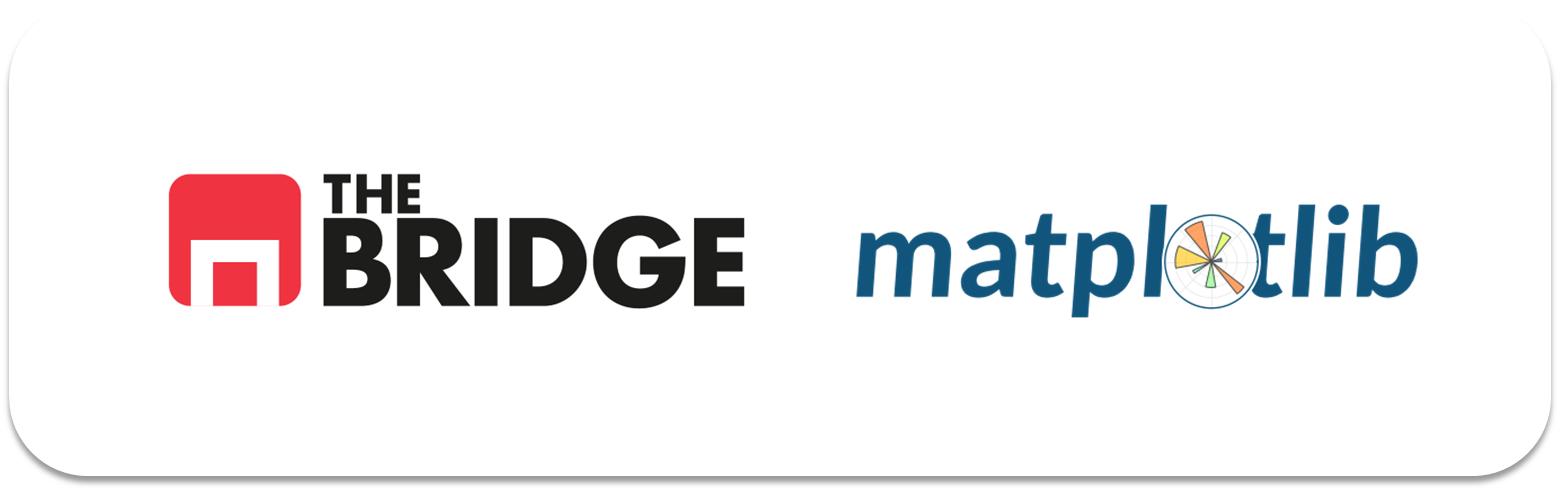

## PRACTICA OBLIGATORIA: **Visualización Básica**


* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.

* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  

* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 

* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df_california = pd.read_csv("./data/california_cities.csv")
print(df_california.head())
print(df_california.describe())
df_california = df_california.dropna()

   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  area_water_km2  area_water_p

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

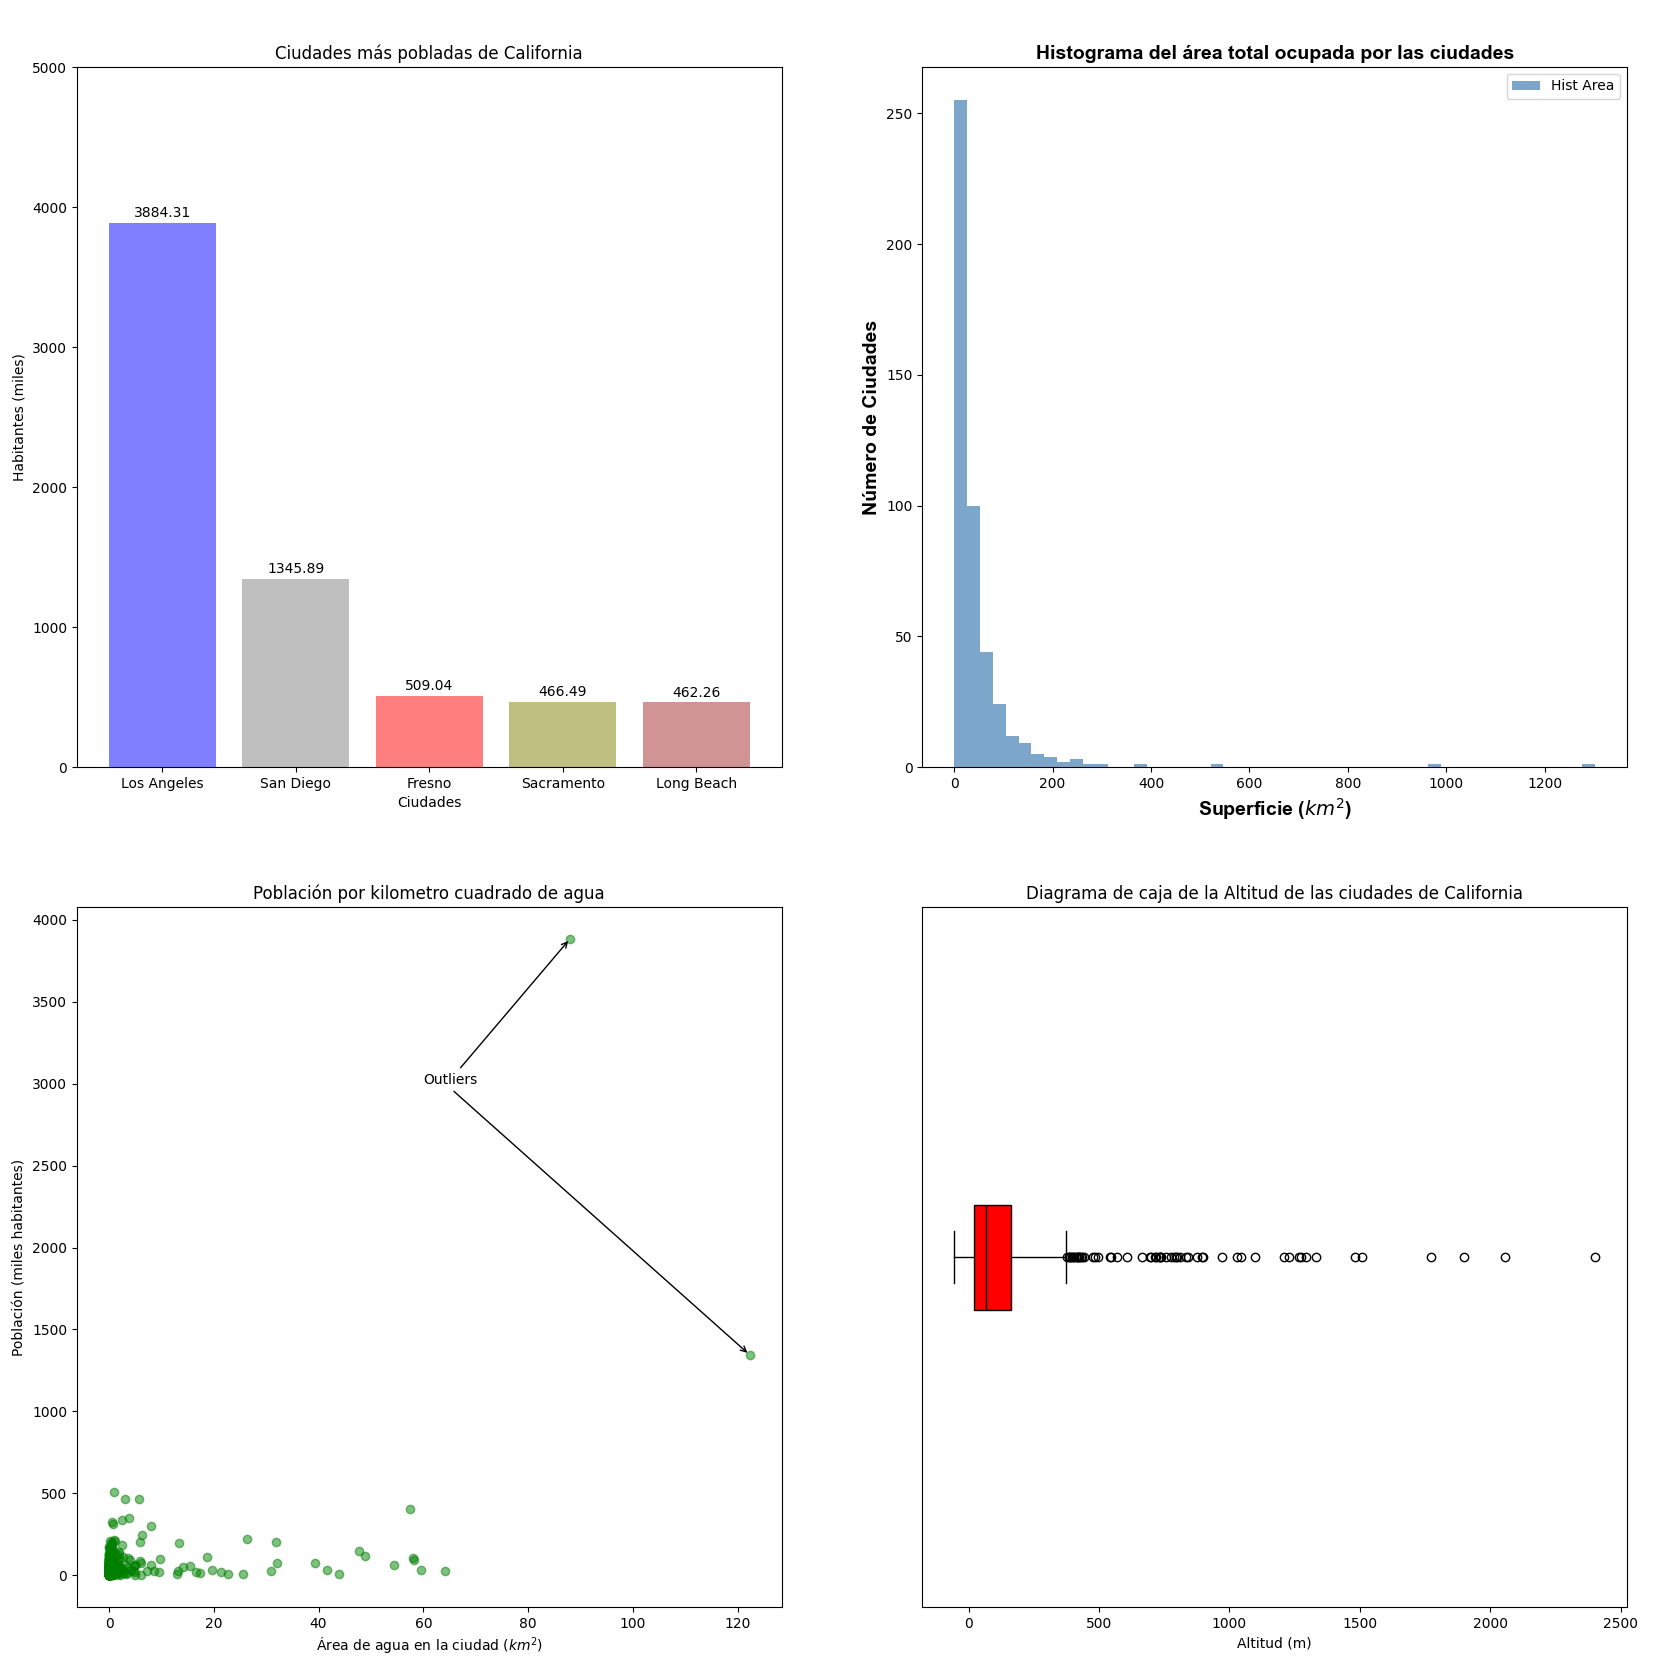

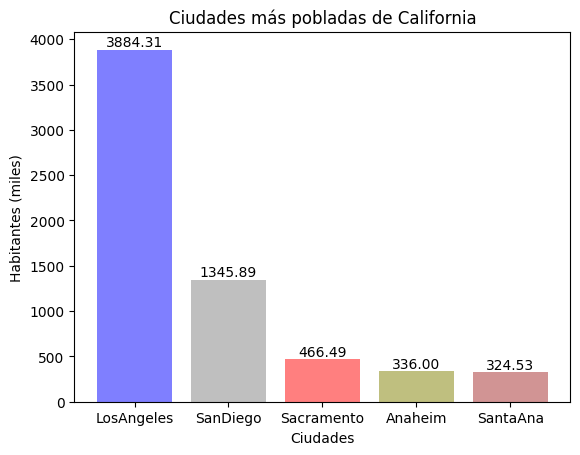

In [5]:
# Ciudades más pobladas
top5 = df_california.nlargest(5, "population_total")[["city", "population_total"]].reset_index(drop=True)
top5["population_miles"] = top5["population_total"] / 1000

colores = ["blue", "gray", "red", "olive", "brown"]

fig, ax = plt.subplots()
bars = ax.bar(top5["city"], top5["population_miles"], color=colores, alpha=0.5)
ax.bar_label(bars, labels=[f"{v:.2f}" for v in top5["population_miles"]])
ax.set_title("Ciudades más pobladas de California")
ax.set_ylabel("Habitantes (miles)")
ax.set_xlabel("Ciudades")
plt.show()

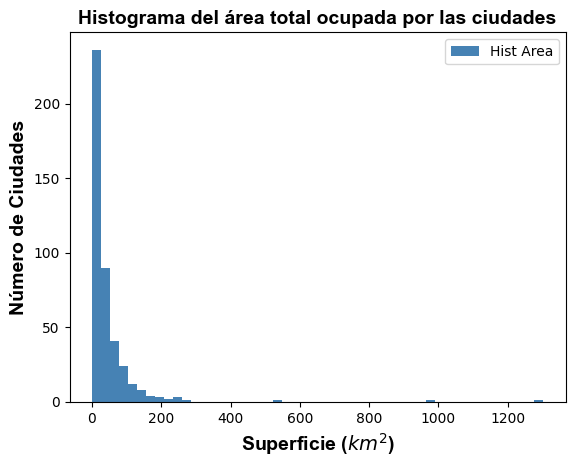

In [7]:
# Histograma del área total ocupada por las ciudades
fig, ax = plt.subplots()
ax.hist(df_california["area_total_km2"], bins=50, color="steelblue", label="Hist Area")
ax.set_title("Histograma del área total ocupada por las ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax.set_xlabel("Superficie ($km^2$)", fontname="Arial", fontsize=14, fontweight="bold")
ax.set_ylabel("Número de Ciudades", fontname="Arial", fontsize=14, fontweight="bold")
ax.legend()
plt.show()

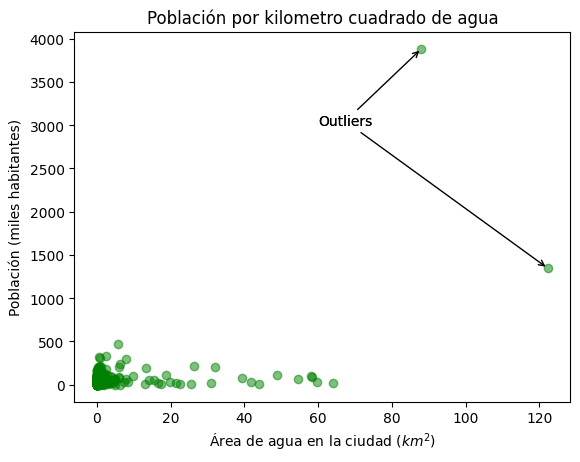

In [11]:
# El scatter de área de agua de un ciudad con su poblacion
fig, ax = plt.subplots()
ax.scatter(df_california["area_water_km2"], df_california["population_total"]/1000, 
           alpha=0.5, color="green")
ax.set_title("Población por kilometro cuadrado de agua")
ax.set_xlabel("Área de agua en la ciudad ($km^2$)")
ax.set_ylabel("Población (miles habitantes)")

# Outliers
outliers = df_california.nlargest(2, "population_total")
for _, row in outliers.iterrows():
    ax.annotate("Outliers", xy=(row["area_water_km2"], row["population_total"]/1000),
                xytext=(60, 3000), arrowprops=dict(arrowstyle="->"))

plt.show()

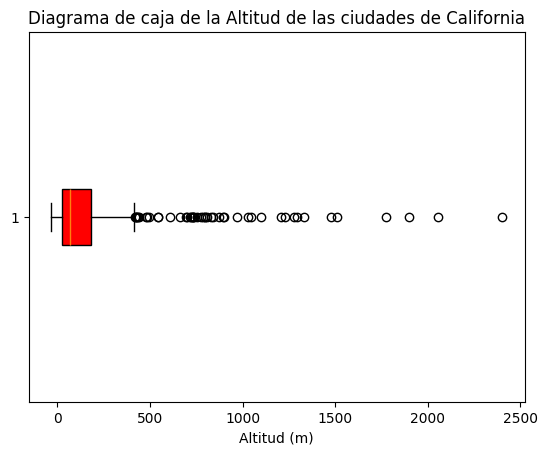

In [12]:
#  El boxplot de la altura de las ciudades
fig, ax = plt.subplots()
ax.boxplot(df_california["elevation_m"].dropna(), vert=False, 
           patch_artist=True,
           boxprops=dict(facecolor="red"))
ax.set_title("Diagrama de caja de la Altitud de las ciudades de California")
ax.set_xlabel("Altitud (m)")
plt.show()

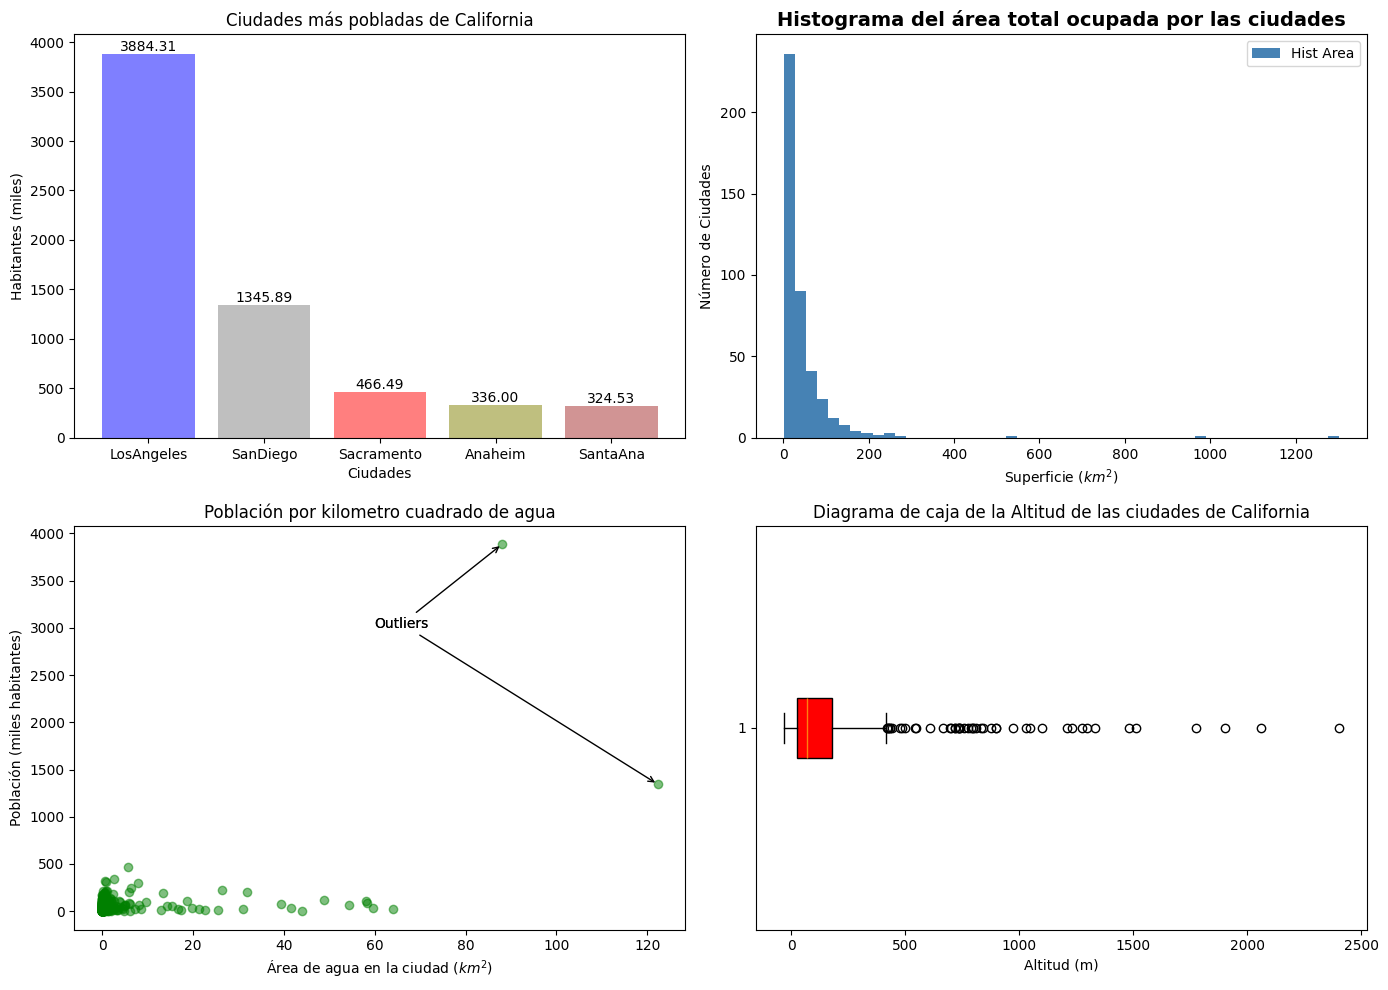

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1 - Ciudades más pobladas
bars = axes[0,0].bar(top5["city"], top5["population_miles"], color=colores, alpha=0.5)
axes[0,0].bar_label(bars, labels=[f"{v:.2f}" for v in top5["population_miles"]])
axes[0,0].set_title("Ciudades más pobladas de California")
axes[0,0].set_ylabel("Habitantes (miles)")
axes[0,0].set_xlabel("Ciudades")

# Gráfica 2 - Histograma
axes[0,1].hist(df_california["area_total_km2"], bins=50, color="steelblue", label="Hist Area")
axes[0,1].set_title("Histograma del área total ocupada por las ciudades", fontsize=14, fontweight="bold")
axes[0,1].set_xlabel("Superficie ($km^2$)")
axes[0,1].set_ylabel("Número de Ciudades")
axes[0,1].legend()

# Gráfica 3 - Scatter
axes[1,0].scatter(df_california["area_water_km2"], df_california["population_total"]/1000, alpha=0.5, color="green")
axes[1,0].set_title("Población por kilometro cuadrado de agua")
axes[1,0].set_xlabel("Área de agua en la ciudad ($km^2$)")
axes[1,0].set_ylabel("Población (miles habitantes)")
for _, row in outliers.iterrows():
    axes[1,0].annotate("Outliers", xy=(row["area_water_km2"], row["population_total"]/1000),
                xytext=(60, 3000), arrowprops=dict(arrowstyle="->"))

# Gráfica 4 - Boxplot
axes[1,1].boxplot(df_california["elevation_m"].dropna(), vert=False,
                  patch_artist=True, boxprops=dict(facecolor="red"))
axes[1,1].set_title("Diagrama de caja de la Altitud de las ciudades de California")
axes[1,1].set_xlabel("Altitud (m)")

plt.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [14]:
fig.savefig("./california_ciudades.png", dpi=150, bbox_inches="tight")